In [15]:
!pip install torch pandas scikit-learn tqdm kagglehub sentencepiece matplotlib

In [16]:
!pip install torch torchvision torchaudio
!pip install pandas numpy matplotlib tqdm scikit-learn
!pip install torch-directml
!pip install wandb

In [16]:
import math
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

try:
    import torch_directml
    DEVICE = torch_directml.device()
    print("Using AMD GPU via DirectML")
except ImportError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {DEVICE}")

Using AMD GPU via DirectML


In [17]:
LINES_FILE = 'movie_lines.txt'
CONVERSATIONS_FILE = 'movie_conversations.txt'

In [18]:
def load_lines(filename):
    lines = {}
    with open(filename, 'r', encoding='iso-8859-1') as f:
        for line in f:
            parts = line.strip().split(' +++$+++ ')
            if len(parts) == 5:
                line_id, character_id, movie_id, character_name, text = parts
                lines[line_id] = text
    return lines


def load_conversations(filename):
    conversations = []
    with open(filename, 'r', encoding='iso-8859-1') as f:
        for line in f:
            parts = line.strip().split(' +++$+++ ')
            utterance_ids = eval(parts[-1])
            conversations.append(utterance_ids)
    return conversations

lines = load_lines(LINES_FILE)
conversations = load_conversations(CONVERSATIONS_FILE)


In [19]:
def build_examples(lines, conversations, max_history=4):
    examples = []
    for conv in conversations:
        utterances = [lines[u] for u in conv if u in lines]
        for i in range(1, len(utterances)):
            start = max(0, i - max_history)
            context = ' '.join(utterances[start:i])
            target = utterances[i]
            text = f'<SCENE> Dialogue continuation <DIALOGUE> {context} <RESPONSE> {target} <EOS>'
            examples.append(text)
    return examples

examples = build_examples(lines, conversations)
print(f'Total examples: {len(examples):,}')

Total examples: 221,367


In [20]:
SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<SCENE>', '<DIALOGUE>', '<RESPONSE>', '<EOS>']
import re

def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

vocab = {}
word_freq = {}
for example in examples:
    for token in tokenize(example):
        word_freq[token] = word_freq.get(token, 0) + 1

for token in SPECIAL_TOKENS:
    vocab[token] = len(vocab)

MIN_FREQ = 5
for word, freq in word_freq.items():
    if freq >= MIN_FREQ and word not in vocab:
        vocab[word] = len(vocab)

itos = {i: t for t, i in vocab.items()}
print(f'Vocabulary size: {len(vocab):,}')

PAD_ID = vocab['<PAD>']
UNK_ID = vocab['<UNK>']

def encode(text):
    return [vocab.get(tok, UNK_ID) for tok in tokenize(text)]

def decode(ids):
    return ' '.join(itos.get(i, '<UNK>') for i in ids)

# Analyze sequence lengths
lengths = [len(encode(text)) for text in examples]

print(f"Average length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95 * len(lengths))]}")
print(f"Maximum length: {max(lengths)}")

Vocabulary size: 28,951
Average length: 63.9
95th percentile: 136
Maximum length: 785


In [21]:
MAX_LEN = 128

class DialogueDataset(Dataset):
    def __init__(self, texts):
        self.data = [encode(text)[:MAX_LEN] for text in texts]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data[idx]
        x = tokens[:-1]
        y = tokens[1:]
        return torch.tensor(x), torch.tensor(y)


def collate_fn(batch):
    xs, ys = zip(*batch)
    x_padded = nn.utils.rnn.pad_sequence(xs, batch_first=True, padding_value=PAD_ID)
    y_padded = nn.utils.rnn.pad_sequence(ys, batch_first=True, padding_value=PAD_ID)
    return x_padded, y_padded

train_texts, val_texts = train_test_split(examples, test_size=0.1, random_state=42)
train_dataset = DialogueDataset(train_texts)
val_dataset = DialogueDataset(val_texts)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)

In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=4,
                 dim_feedforward=512, max_len=128, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def generate_causal_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        return mask.bool().to(DEVICE)

    def forward(self, x):
        seq_len = x.size(1)
        mask = self.generate_causal_mask(seq_len)
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.transformer(x, mask=mask)
        return self.lm_head(x)

model = DecoderOnlyTransformer(len(vocab)).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters()):,}')

Trainable parameters: 8,233,495


In [23]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [24]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in tqdm(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(loader)

In [25]:
EPOCHS = 10
PATIENCE = 2

train_losses, val_losses = [], []

import math
import torch
import wandb

best_val_loss = float("inf")
patience_counter = 0

wandb.init(
    project="dialogue-transformer",
    config={
        "batch_size": 32,
        "max_len": 128,
        "d_model": 128,
        "n_layers": 4,
        "n_heads": 4,
        "learning_rate": 1e-4,
        "patience": PATIENCE
    }
)


epoch,▁█
lr,▁▁
train/loss,█▁
train/perplexity,█▁
val/loss,█▁
val/perplexity,█▁
epoch,7
lr,0.0003
train/loss,2.96649
train/perplexity,19.4237
val/loss,2.93245


In [26]:
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/perplexity": math.exp(train_loss),
        "val/loss": val_loss,
        "val/perplexity": math.exp(val_loss),
        "lr": optimizer.param_groups[0]["lr"]
    })

    # Save checkpoint every epoch
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss
    }, f"checkpoint_epoch_{epoch+1}.pt")

    # Early stopping + best model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss
        }, "best_model.pt")

        print("Best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter}/{PATIENCE} epoch(s).")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered after epoch {epoch+1}.")
        break

wandb.finish()

  0%|          | 0/6226 [00:00<?, ?it/s]

Best model saved.
Epoch 1/10
  Train Loss: 3.6238
  Val Loss:   3.3112


  0%|          | 0/6226 [00:00<?, ?it/s]

Best model saved.
Epoch 2/10
  Train Loss: 3.2820
  Val Loss:   3.1713


  0%|          | 0/6226 [00:00<?, ?it/s]

...

  0%|          | 0/6226 [00:00<?, ?it/s]

Best model saved.
Epoch 9/10
  Train Loss: 2.9160
  Val Loss:   2.8897


  0%|          | 0/6226 [00:00<?, ?it/s]

Best model saved.
Epoch 10/10
  Train Loss: 2.8953
  Val Loss:   2.8750


epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▄▃▂▂▂▁▁▁
train/perplexity,█▄▃▂▂▂▁▁▁▁
val/loss,█▆▄▃▃▂▂▂▁▁
val/perplexity,█▅▄▃▃▂▂▁▁▁
epoch,10
lr,0.0003
train/loss,2.89531
train/perplexity,18.08917
val/loss,2.87502


In [15]:
EPOCHS = 10
# A REMPLACER PAR LE VRAI CHECKPOINT
checkpoint = torch.load("checkpoint_epoch_5.pt", map_location="cpu")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model = model.to(DEVICE)

start_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["val_loss"]

print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/perplexity": math.exp(train_loss),
        "val/loss": val_loss,
        "val/perplexity": math.exp(val_loss),
        "lr": optimizer.param_groups[0]["lr"]
    })

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss
    }, f"checkpoint_epoch_{epoch+1}.pt")

C:\Users\Sami\AppData\Local\Temp\ipykernel_22048\3549427141.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoint_epoch_5.pt", map_location

Resuming from epoch 5


  0%|          | 0/6226 [00:00<?, ?it/s]

  0%|          | 0/6226 [00:00<?, ?it/s]

  0%|          | 0/6226 [00:00<?, ?it/s]

KeyboardInterrupt: 

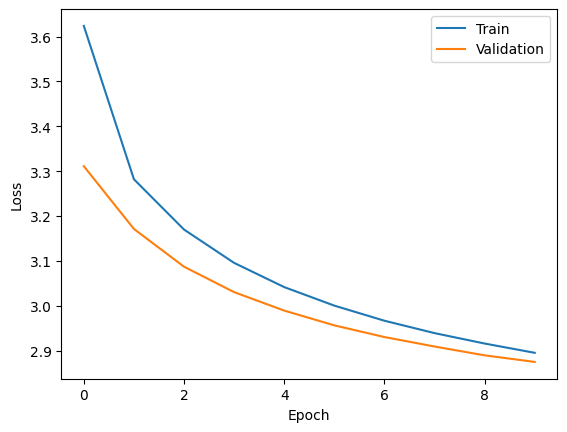

In [31]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [32]:
def generate(model, prompt, max_new_tokens=50, temperature=0.8):
    model.eval()
    tokens = encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_tokens = tokens[:, -MAX_LEN:]
            logits = model(input_tokens)
            next_token_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            tokens = torch.cat([tokens, next_token], dim=1)

            if next_token.item() == vocab['<EOS>']:
                break

    return decode(tokens[0].tolist())

In [33]:
prompt = '<SCENE> Dialogue continuation <DIALOGUE> where were you last night ? <RESPONSE>'
result = generate(model, prompt)
print(result)

< scene > dialogue continuation < dialogue > where were you last night ? < response > they put my finger on now . < eos > their money . < eos > it ' s a wonderful thing that ' s all ! < eos > i ' m just saying it and i ' m listening to be said that " holy " ? "


In [37]:
prompt = '<SCENE> Dialogue continuation <DIALOGUE> I thought you said you would be home early ? <RESPONSE>'
result = generate(model, prompt)
print(result)

prompt = "<SCENE> Dialogue continuation <DIALOGUE> why didn't you answer my calls yesterday ? <RESPONSE>"
result = generate(model, prompt)
print(result)

prompt = '<SCENE> Dialogue continuation <DIALOGUE> we need to talk about what happened at school <RESPONSE>'
result = generate(model, prompt)
print(result)

prompt = '<SCENE> Dialogue continuation <DIALOGUE> do you really think we should trust him ? <RESPONSE>'
result = generate(model, prompt)
print(result)

prompt = "<SCENE> Dialogue continuation <DIALOGUE> I still don't understand why you left without saying anything <RESPONSE>"
result = generate(model, prompt)
print(result)

< scene > dialogue continuation < dialogue > i thought you said you would be home early ? < response > i ' d first dibs up in this one day . < eos > your name ' s tom . < eos > you don ' t have any idea for a chance to meet me , mr . thatcher . i just wanted to ask you for this to
< scene > dialogue continuation < dialogue > why didn ' t you answer my calls yesterday ? < response > i didn ' t come on the meeting last night . < eos > you ' ve had an affair with me . < eos > you don ' t want to find the police department . < eos > how you are <UNK> as long as you ' re
< scene > dialogue continuation < dialogue > we need to talk about what happened at school < response > i can ' t take care of us . < eos > how ' bout coffee ? < eos > good . < eos > all right , right ? < eos > i ' ll be my guest . < eos > money , and we ' ll have
< scene > dialogue continuation < dialogue > do you really think we should trust him ? < response > i ' m trying to reach me . if you have to take me a walk once 

In [34]:
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'config': {
        'vocab_size': len(vocab)
    }
}, 'dialogue_transformer_scratch.pth')
